In [1]:
# Setup
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recsys.config import load_config, set_seed
from recsys import plots
cfg = load_config()
set_seed(cfg["seed"])
plots.set_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
import json
from recsys import pipeline as P, eda, evaluate as E, ranker as R
from recsys.candidates import SOURCE_RANKS
from recsys.data import load_dataset, history
ds = load_dataset(cfg)

In [2]:
# 1. Candidate + feature tables per week (built once, cached)
P.build_tables(cfg, ds)
summary = eda.table_summary(cfg, P.load_week)
summary.to_csv(cfg["paths"]["tables"] / "table_summary.csv", index=False)
summary

,week,role,rows,customers,candidates_per_customer,positives,positive_rate,candidate_recall,customers_with_a_positive
0,0,test,1142923,14023,81.5035,4875,0.0043,0.1118,0.2556
1,1,valid,1191921,14753,80.7918,4587,0.0038,0.0978,0.2357
2,2,train,1224915,15368,79.7056,4828,0.0039,0.1006,0.2412
3,3,train,1340176,16345,81.9930,4973,0.0037,0.0947,0.2341
4,4,train,1264202,14641,86.3467,4424,0.0035,0.0948,0.2264


,source,rows,candidate_recall
0,Buy again,57647,0.0262
1,Item-to-item CF,172248,0.0058
2,ALS,173020,0.0188
3,Content-based (PCA),173020,0.0082
4,Other colors,73786,0.0134
5,Best sellers,504828,0.0547
6,Age-band best sellers,168276,0.0225
7,All combined,1142923,0.1118


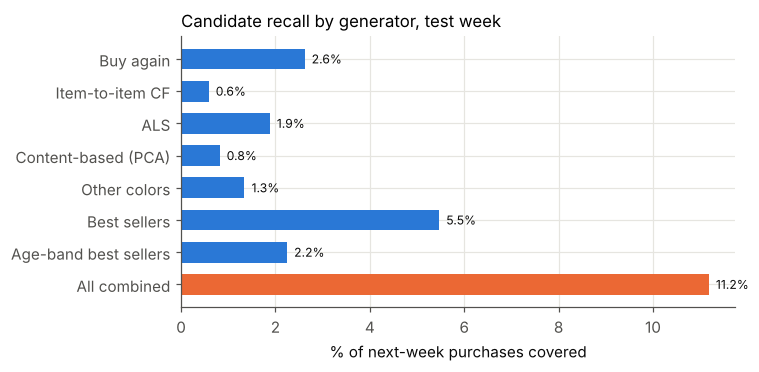

In [3]:
# 2. Candidate recall by source (test week)
test, tx = P.load_week(cfg, cfg["weeks"]["test"])
rbs = eda.recall_by_source(test, tx["actual"], SOURCE_RANKS)
rbs.to_csv(cfg["paths"]["tables"] / "candidate_recall_by_source.csv", index=False)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.barh(rbs["source"][::-1], rbs["candidate_recall"][::-1] * 100, color=[plots.ORANGE] + [plots.BLUE] * (len(rbs) - 1), height=0.65)
[ax.text(v * 100 + 0.15, i, f"{v * 100:.1f}%", va="center", fontsize=8, color=plots.INK) for i, v in enumerate(rbs["candidate_recall"][::-1])]
ax.set_xlabel("% of next-week purchases covered")
ax.set_title("Candidate recall by generator, test week")
plots.save(fig, "03_candidate_recall")
rbs

In [4]:
# 3. Train and tune the rankers (or load the saved run)
meta_path = cfg["paths"]["models"] / "model_meta.json"
trained = P.load_trained(cfg) if meta_path.exists() else P.train(cfg)
meta = json.loads(meta_path.read_text())
pd.DataFrame(meta["valid_metrics"]).T

,map@12,recall@12,ndcg@12,hit_rate,customers,C,valid_auc,fit_seconds,best_iteration
logreg,0.0273,0.0592,0.0407,0.1165,"14,753.0000",0.1000,0.7410,27.0268,NaN
lgbm_classifier,0.0305,0.0642,0.0452,0.1269,"14,753.0000",NaN,0.7680,52.5373,137.0000
lgbm_ranker,0.0301,0.0632,0.0446,0.1249,"14,753.0000",NaN,0.7588,32.9391,132.0000


In [5]:
# 4. Tuning results (random search, selected on validation MAP@12)
tun = pd.read_csv(cfg["paths"]["tables"] / "tuning_lgbm_classifier.csv").sort_values("map@12", ascending=False)
tun[["trial", "num_leaves", "learning_rate", "min_child_samples", "colsample_bytree", "subsample", "reg_lambda", "best_iteration", "map@12", "valid_auc"]].head(10)

,trial,num_leaves,learning_rate,min_child_samples,colsample_bytree,subsample,reg_lambda,best_iteration,map@12,valid_auc
3,3,127,0.0500,200,0.7000,0.6000,5.0000,137,0.0305,0.7680
7,7,63,0.0500,50,0.9000,0.8000,5.0000,221,0.0302,0.7684
1,1,15,0.1000,50,0.5000,0.8000,5.0000,301,0.0301,0.7672
5,5,31,0.0500,50,0.7000,1.0000,0.0000,120,0.0296,0.7614
6,6,127,0.1000,100,0.7000,0.6000,5.0000,63,0.0294,0.7669
2,2,63,0.1000,200,0.9000,0.8000,0.0000,61,0.0294,0.7636
0,0,15,0.1000,200,0.7000,0.8000,5.0000,178,0.0293,0.7639
4,4,127,0.1000,100,0.9000,0.8000,1.0000,54,0.0291,0.7638


In [6]:
# 5. Logistic regression and LambdaRank tuning
pd.concat([pd.read_csv(cfg["paths"]["tables"] / "tuning_logreg.csv").assign(model="logreg"), pd.read_csv(cfg["paths"]["tables"] / "tuning_lgbm_ranker.csv").assign(model="lgbm_ranker")])[["model", "C", "num_leaves", "learning_rate", "best_iteration", "map@12", "valid_auc"]]

,model,C,num_leaves,learning_rate,best_iteration,map@12,valid_auc
0,logreg,0.1000,NaN,NaN,NaN,0.0273,0.7410
1,logreg,1.0000,NaN,NaN,NaN,0.0272,0.7412
0,lgbm_ranker,NaN,63.0000,0.1000,41.0000,0.0297,0.7633
1,lgbm_ranker,NaN,31.0000,0.1000,49.0000,0.0294,0.7580
2,lgbm_ranker,NaN,127.0000,0.1000,36.0000,0.0296,0.7566
3,lgbm_ranker,NaN,63.0000,0.0500,132.0000,0.0301,0.7588


In [7]:
# 6. Test-week comparison of every model (week 0, never used for training or tuning)
res = P.evaluate_test(cfg, trained)
res.to_csv(cfg["paths"]["tables"] / "model_comparison_test.csv", index=False)
res

,stage,model,map@12,recall@12,ndcg@12,hit_rate,customers,coverage,auc,candidate_recall
0,1 candidate,Best sellers,0.0094,0.0284,0.0171,0.0714,14023,0.0005,NaN,0.1118
1,1 candidate,Age-band best sellers,0.0092,0.0271,0.0165,0.0665,14023,0.0019,NaN,0.1118
2,1 candidate,Buy again,0.0263,0.0557,0.0389,0.1121,14023,0.5443,NaN,0.1118
3,1 candidate,Item-to-item CF,0.0049,0.0161,0.0094,0.0391,14023,0.7737,NaN,0.1118
4,1 candidate,ALS matrix factorization,0.0089,0.0271,0.0164,0.0647,14023,0.0715,NaN,0.1118
5,1 candidate,Content-based (PCA),0.0050,0.0171,0.0097,0.0424,14023,0.1236,NaN,0.1118
6,1 candidate,Other colors,0.0117,0.0338,0.0208,0.0781,14023,0.3044,NaN,0.1118
7,2 ranker,Logistic regression,0.0293,0.0620,0.0432,0.1202,14023,0.2963,0.7301,0.1118
8,2 ranker,LightGBM classifier,0.0309,0.0663,0.0461,0.1312,14023,0.2902,0.7584,0.1118
9,2 ranker,LightGBM LambdaRank,0.0312,0.0648,0.0457,0.1274,14023,0.2932,0.7555,0.1118


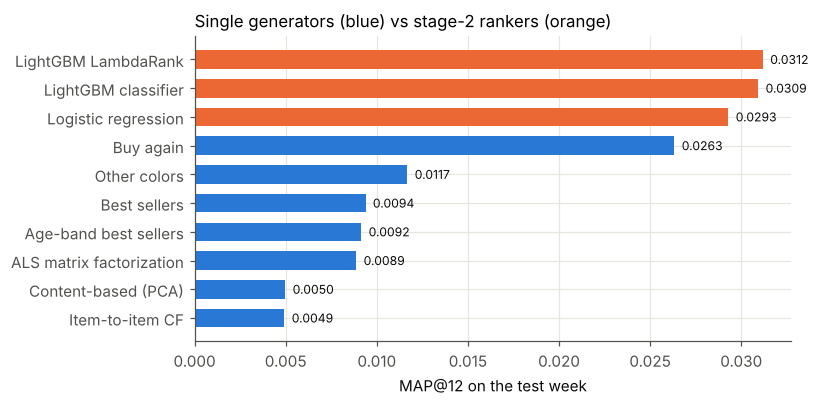

In [8]:
# 7. MAP@12 by model
r = res.sort_values("map@12")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(r["model"], r["map@12"], color=[plots.ORANGE if s == "2 ranker" else plots.BLUE for s in r["stage"]], height=0.65)
[ax.text(v + 0.0004, i, f"{v:.4f}", va="center", fontsize=8, color=plots.INK) for i, v in enumerate(r["map@12"])]
ax.set_xlabel("MAP@12 on the test week")
ax.set_title("Single generators (blue) vs stage-2 rankers (orange)")
plots.save(fig, "03_model_comparison")

In [9]:
# 8. Overfitting check: train vs validation vs test for the best model
fit = P.overfit_table(cfg, trained, "lgbm_classifier")
fit.to_csv(cfg["paths"]["tables"] / "overfit_check.csv", index=False)
fit

,split,weeks,map@12,recall@12,hit_rate,auc
0,train,3,0.0420,0.0778,0.1604,0.8556
1,valid,1,0.0305,0.0642,0.1269,0.7680
2,test,1,0.0309,0.0663,0.1312,0.7584


split,rounds,test_map@12,valid_map@12
0,10,0.0305,0.0289
1,25,0.0309,0.0297
2,50,0.0312,0.0299
3,75,0.0311,0.0304
4,100,0.0309,0.0305
5,125,0.0310,0.0306


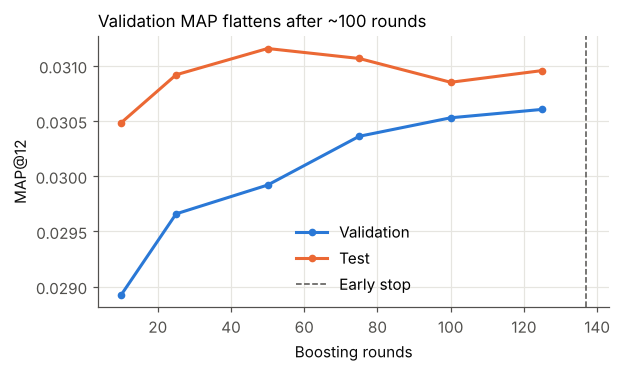

In [10]:
# 9. Validation and test MAP@12 by number of boosting rounds
curve = P.rounds_curve(cfg, trained, [10, 25, 50, 75, 100, 125, 150, 175])
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(curve["rounds"], curve["valid_map@12"], color=plots.BLUE, marker="o", ms=4, lw=2, label="Validation")
ax.plot(curve["rounds"], curve["test_map@12"], color=plots.ORANGE, marker="o", ms=4, lw=2, label="Test")
ax.axvline(trained["models"]["lgbm_classifier"].best_iteration_, color=plots.GRAY, ls="--", lw=1, label="Early stop")
ax.set_xlabel("Boosting rounds")
ax.set_ylabel("MAP@12")
ax.legend()
ax.set_title("Validation MAP flattens after ~100 rounds")
plots.save(fig, "03_rounds_curve")
curve

In [11]:
# 10. Warm vs cold customers (best ranker vs popularity)
hist0 = history(ds.transactions, cfg["weeks"]["test"], cfg["weeks"]["history_weeks"])
warm = set(hist0["cid"])
best_pred = P.predictions(cfg, trained, "lgbm_classifier", test)
per_best = E.per_customer_metrics(tx["actual"], best_pred, 12, tx["popular"])
per_pop = E.per_customer_metrics(tx["actual"], tx["per_source"]["popularity"], 12, tx["popular"])
wc = eda.warm_cold(per_best, warm).merge(eda.warm_cold(per_pop, warm)[["segment", "map12"]].rename(columns={"map12": "popularity_map12"}), on="segment")
wc.to_csv(cfg["paths"]["tables"] / "warm_cold.csv", index=False)
wc

,segment,customers,map12,hit_rate,popularity_map12
0,has 8-week history,8651,0.0448,0.1668,0.0101
1,no history (cold),5372,0.0086,0.0739,0.0083


In [12]:
# 11. Saved artifacts and MLflow runs
import mlflow
mlflow.set_tracking_uri(f"sqlite:///{cfg['paths']['mlflow'] / 'mlflow.db'}")
runs = mlflow.search_runs(experiment_names=["hm-recommender"])
print(sorted(p.name for p in cfg["paths"]["models"].iterdir()))
runs[["tags.mlflow.runName", "metrics.map_at_12", "metrics.recall_at_12", "metrics.valid_auc", "start_time"]]

['lgbm_classifier.joblib', 'lgbm_classifier.txt', 'lgbm_ranker.joblib', 'lgbm_ranker.txt', 'logreg.joblib', 'model_meta.json', 'test_metrics.json']


,tags.mlflow.runName,metrics.map_at_12,metrics.recall_at_12,metrics.valid_auc,start_time
0,lgbm_ranker,0.0301,0.0632,0.7588,2026-10-07 17:18:20.899000+00:00
1,lgbm_classifier,0.0305,0.0642,0.7680,2026-10-07 17:16:55.531000+00:00
2,logreg,0.0273,0.0592,0.7410,2026-10-07 17:11:16.546000+00:00
